# TPC-C Collector Demo MT



In [1]:
import pandas as pd
pd.set_option("display.max_rows", None)
pd.set_option('display.max_colwidth', None)

from bexhoma import collectors

%matplotlib inline

# Functions for Nice Plots

In [2]:
from notebookutils import *

# Collect Results

In [3]:
path = r"D:\data\benchmarks"
#path = r"/data/benchmarks"
filename_prefix = "demo_"
b_plot_save = False
b_skip_plots = True

In [4]:
codes = [
    "1776011403",
    "1776009655",
    "1776007886"
]

codes

['1776011403', '1776009655', '1776007886']

In [5]:
collect = collectors.default(path, codes)

# Get all Metrics Metadata

## Metrics Names and Types

Metrics that are derived from monitoring

In [6]:
collect.df_metrics

,title,active,type,metric
total_cpu_memory,Memory Usage [MiB],True,cluster,gauge
total_cpu_memory_cached,Memory Usage Cached [MiB],True,cluster,gauge
total_cpu_util,CPU Utilization,True,cluster,gauge
total_cpu_throttled,CPU Throttle,True,cluster,gauge
total_cpu_throttled_s,CPU Throttled Time [s],True,cluster,counter
total_cpu_util_others,CPU Utilization Others,False,cluster,gauge
total_cpu_util_s,CPU Utilization Time [s],True,cluster,counter
total_cpu_util_user_s,CPU User Time [s],True,cluster,counter
total_cpu_util_sys_s,CPU System Time [s],True,cluster,counter
total_cpu_util_others_s,CPU Utilization Time Others [s],False,cluster,counter


## Names of Monitored Phases

Names of components and their phases

In [7]:
collect.get_monitored_phases()

,description
loading,Loading phase: SUT deployment
datagenerator,Loading phase: component data generator
loader,Loading phase: component loader
stream,Execution phase: SUT deployment
benchmarker,Execution phase: component benchmarker


# Get Connection Infos

List of drivers, aggregated by parallel runnings

In [8]:
collect.get_connections()

,code,experiment_run,client,dockerimage,name,time_load,time_ingest,time_check,terminals,pods,tenant,datadisk
PostgreSQL-BHT-1-0-1-1-1,1776011403,1,1,postgres:18.3,PostgreSQL-BHT-1-0-1-1-1,712.0,289.0,416.0,0,1,0,0
PostgreSQL-BHT-1-0-1-2-1,1776011403,1,2,postgres:18.3,PostgreSQL-BHT-1-0-1-2-1,712.0,289.0,416.0,0,1,0,0
PostgreSQL-BHT-1-0-2-1-1,1776011403,2,1,postgres:18.3,PostgreSQL-BHT-1-0-2-1-1,712.0,289.0,416.0,0,1,0,0
PostgreSQL-BHT-1-0-2-2-1,1776011403,2,2,postgres:18.3,PostgreSQL-BHT-1-0-2-2-1,712.0,289.0,416.0,0,1,0,0
PostgreSQL-BHT-1-1-1-1-1,1776011403,1,1,postgres:18.3,PostgreSQL-BHT-1-1-1-1-1,711.0,289.0,419.0,0,1,1,0
PostgreSQL-BHT-1-1-1-2-1,1776011403,1,2,postgres:18.3,PostgreSQL-BHT-1-1-1-2-1,711.0,289.0,419.0,0,1,1,0
PostgreSQL-BHT-1-1-2-1-1,1776011403,2,1,postgres:18.3,PostgreSQL-BHT-1-1-2-1-1,711.0,289.0,419.0,0,1,1,0
PostgreSQL-BHT-1-1-2-2-1,1776011403,2,2,postgres:18.3,PostgreSQL-BHT-1-1-2-2-1,711.0,289.0,419.0,0,1,1,0


# Get Aggregated Metrics per SUT and per Experiment

In [9]:
df_performance = collect.get_monitoring_all(type="stream")
df_performance.T

""
experiment_run
client
Memory Usage [MiB]
Memory Usage Cached [MiB]
CPU Utilization
CPU Throttle
CPU Throttled Time [s]
CPU Utilization Time [s]
CPU User Time [s]
CPU System Time [s]


# Bar Plots of Aggregated Values per Metric

In [10]:
if not b_skip_plots:
    for idx, row in collect.df_metrics.iterrows():
        if row["active"] == False:
            continue
        col_name = row["title"]
        plot_bars(df_performance, y=col_name, title=col_name, estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

# Boxplot of All Metrics for a Single Experiment

In [11]:
if not b_skip_plots:
    results = []
    code = codes[0]
    for idx, row in collect.df_metrics.iterrows():
        if row["active"] == False:
            continue
        metric_name = idx
        method = 'diff' if row["metric"] == 'counter' else 'mean'
        col_name = row["title"]
        df_monitoring = collect.get_monitoring_timeseries_single(code, metric=metric_name)
        #print(df_monitoring)
        ax = df_monitoring.boxplot()
        ax.set_title(col_name)
        plt.show()

# Boxplot of A Single Metric for a Single Experiment

In [32]:
metric = 'total_cpu_memory'
code = codes[0]
collect.get_monitoring_timeseries_single(code, metric=metric)

,PostgreSQL-BHT-1-0-1-1,PostgreSQL-BHT-1-0-1-2,PostgreSQL-BHT-1-0-2-1,PostgreSQL-BHT-1-0-2-2,PostgreSQL-BHT-1-1-1-1,PostgreSQL-BHT-1-1-1-2,PostgreSQL-BHT-1-1-2-1,PostgreSQL-BHT-1-1-2-2
0,9764.914062,10328.917969,10342.042969,10309.144531,9764.867188,10328.929688,10328.929688,10303.605469
1,9764.914062,10328.917969,10342.042969,10309.144531,9764.867188,10328.929688,10328.929688,10303.605469
2,9764.914062,10328.917969,10342.042969,10309.144531,9764.867188,10328.929688,10328.929688,10303.605469
3,9764.914062,10328.917969,10342.042969,10309.144531,9764.867188,10328.929688,10328.929688,10303.605469
4,9764.914062,10328.917969,10342.042969,10309.144531,9764.867188,10328.929688,10328.929688,10303.605469
5,9764.914062,10328.917969,10342.042969,10309.144531,9764.867188,10328.929688,10328.929688,10303.605469
6,9764.914062,10328.917969,10342.042969,10309.144531,9764.867188,10328.929688,10328.929688,10303.605469
7,9764.914062,10328.917969,10342.042969,10309.144531,9764.867188,10328.929688,5854.140625,10303.605469
8,9764.914062,10328.917969,10342.042969,10309.144531,9764.867188,10328.929688,6262.210938,10303.605469
9,9764.914062,10328.917969,10342.042969,10309.144531,9764.867188,10328.929688,6262.210938,10303.605469


In [33]:
metric = 'total_cpu_memory'
code = codes[0]
collect.get_monitoring_timeseries_all( metric=metric)

,timestamp,code,experiment_run,client,type,vol_tenants,num_tenants,value


In [14]:
if not b_skip_plots:
    metric = 'pg_stat_activity_max_tx_duration_active'
    #metric = 'pg_stat_database_blks_reads'
    #metric = 'pg_stat_activity_count_idle_transaction'
    metric = 'total_cpu_memory'
    code = codes[0]
    df_monitoring = collect.get_monitoring_timeseries_single(code, metric=metric)
    ax = df_monitoring.boxplot()
    ax.set_title(collect.df_metrics.loc[metric]['title'])#metric)
    plt.show()
    df_monitoring

# Lineplot of a Single Metric for a Single Experiment

In [15]:
if not b_skip_plots:
    code = codes[0]
    metric = 'pg_stat_database_blks_hit'
    metric = 'pg_stat_activity_count_idle_transaction'
    metric = 'total_cpu_memory'
    metric = 'total_cpu_util'
    metric = 'total_cpu_util_s'
    metric = 'core_variance'
    df_monitoring = collect.get_monitoring_timeseries_single(code, metric=metric)
    ax = df_monitoring.plot()
    ax.set_title(metric)
    plt.show()
    #df_monitoring

# Boxplot of a Single Metric for all Experiments

In [16]:
metric = 'pg_stat_database_blks_hit'
metric = 'pg_stat_activity_count_idle_transaction'
metric = 'total_cpu_memory'
metric = 'total_cpu_util'
metric = 'total_cpu_util_s'
metric = 'core_variance'
metric = 'pg_locks_count_exclusivelock'
metric = 'pg_stat_activity_count_active'
df_performance = collect.get_monitoring_timeseries_all(metric)
#df_performance
df_performance_first = df_performance[df_performance['client']=="1"]
#df_performance_first
df_performance_second = df_performance[df_performance['client']=="2"]
#df_performance_second
#df_performance_first['value'].describe()
#df_performance

## First Execution Run

C:\Users\Patrick\eclipse-workspace\Benchmark-Experiment-Host-Manager\dev\notebookutils.py:165: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Type")
C:\Users\Patrick\eclipse-workspace\Benchmark-Experiment-Host-Manager\dev\notebookutils.py:166: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=18)


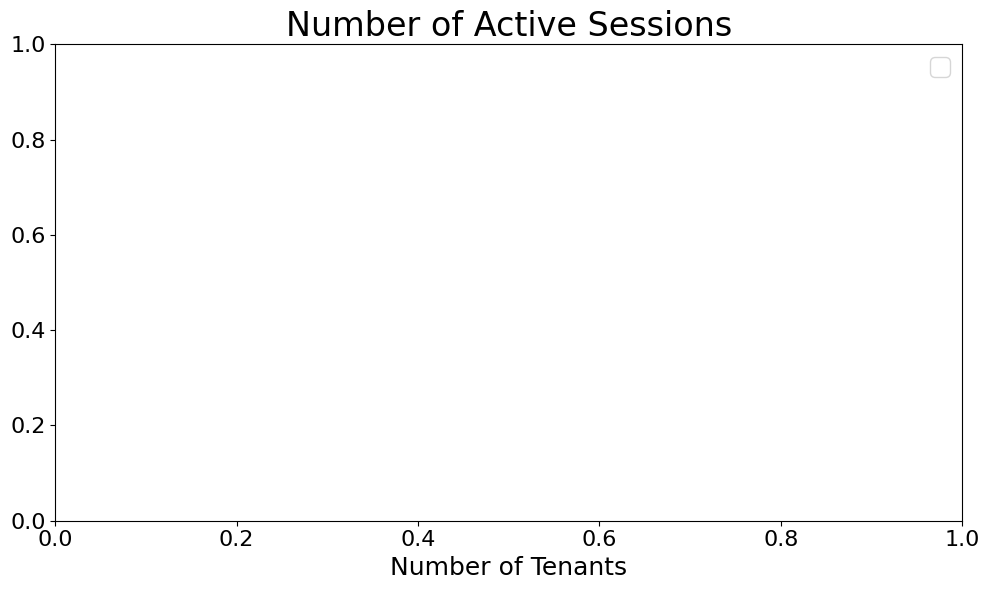

In [17]:
plot_boxplots(df_performance_first, y='value', title=collect.df_metrics.loc[metric]['title'], b_plot_save=b_plot_save, filename_prefix=filename_prefix)

## Second Execution Run

C:\Users\Patrick\eclipse-workspace\Benchmark-Experiment-Host-Manager\dev\notebookutils.py:165: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Type")
C:\Users\Patrick\eclipse-workspace\Benchmark-Experiment-Host-Manager\dev\notebookutils.py:166: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=18)


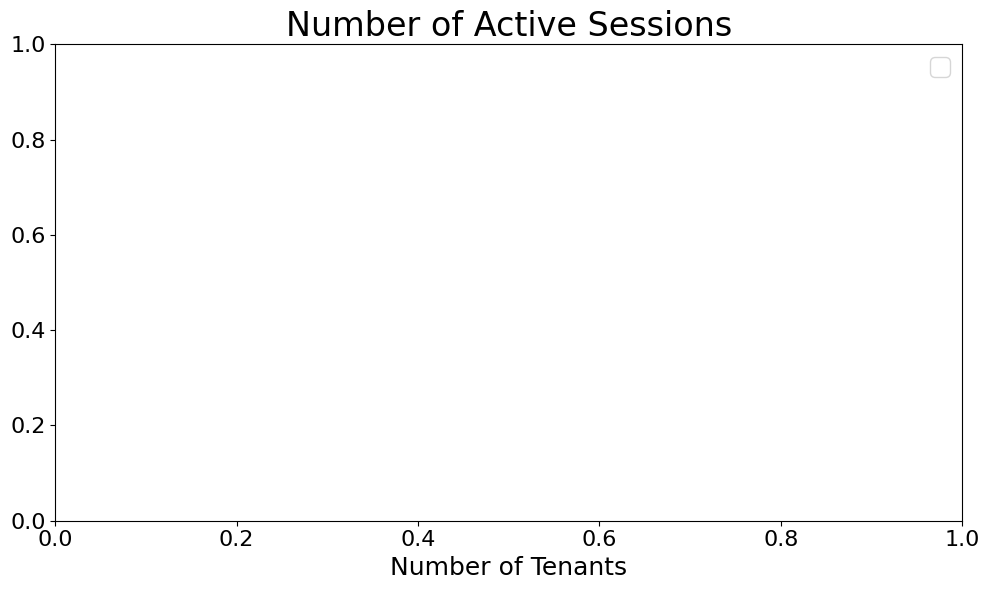

In [18]:
plot_boxplots(df_performance_second, y='value', title=collect.df_metrics.loc[metric]['title'], b_plot_save=b_plot_save, filename_prefix=filename_prefix)

# Lineplot of a Single Metric for All Experiments

## First Execution Run

C:\Users\Patrick\eclipse-workspace\Benchmark-Experiment-Host-Manager\dev\notebookutils.py:187: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  ax = sns.lineplot(


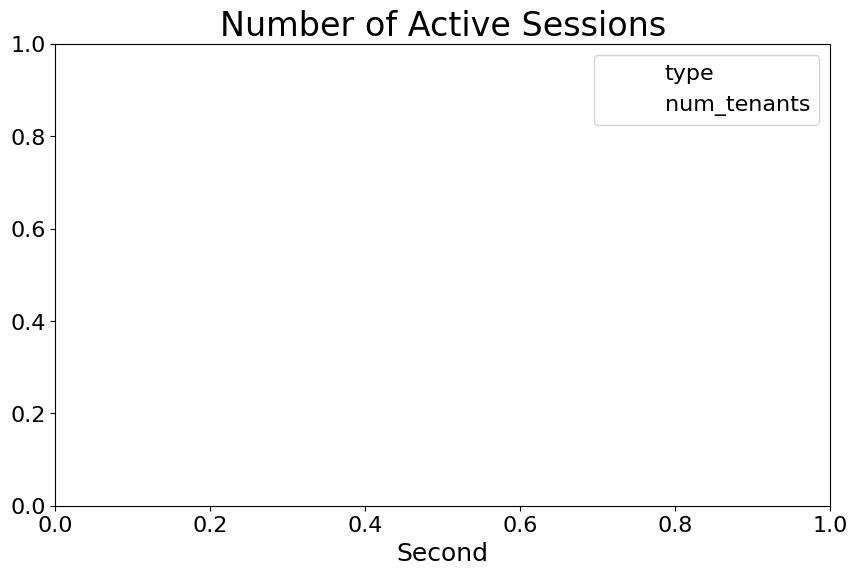

In [19]:
#df = df_performance_first[df_performance_first['type'] == 'None']
#df = df[df['experiment_run'] == '1']
plot_lines(df_performance_first, y='value', title=collect.df_metrics.loc[metric]['title'], b_plot_save=b_plot_save, filename_prefix=filename_prefix)
#df

# Aggregated Data for all Clients

In [20]:
df_performance = collect.get_monitoring_single_all("stream")
df_performance.T

,PostgreSQL-BHT-1-0-1-1,PostgreSQL-BHT-1-0-1-2,PostgreSQL-BHT-1-0-2-1,PostgreSQL-BHT-1-0-2-2,PostgreSQL-BHT-1-1-1-1,PostgreSQL-BHT-1-1-1-2,PostgreSQL-BHT-1-1-2-1,PostgreSQL-BHT-1-1-2-2,PostgreSQL-BHT-2-1-1,PostgreSQL-BHT-2-1-2,PostgreSQL-BHT-2-2-1,PostgreSQL-BHT-2-2-2,PostgreSQL-BHT-2-1-1,PostgreSQL-BHT-2-1-2,PostgreSQL-BHT-2-2-1,PostgreSQL-BHT-2-2-2
Memory Usage [MiB],10057.77,11004.45,8420.76,11231.16,10038.05,10614.75,8137.54,11325.48,14117.06,16514.93,12965.62,14899.88,14331.72,14791.07,13337.56,14935.77
Memory Usage Cached [MiB],14967.65,15914.33,11271.6,16082.4,14947.95,15524.64,10688.02,16181.56,23908.82,26306.68,20420.18,24736.04,24119.78,24579.13,21537.74,24327.15
CPU Utilization,0.87,0.25,0.49,0.58,0.78,0.6,0.43,0.63,2.42,1.15,1.28,2.13,2.91,0.01,1.3,1.42
CPU Throttle,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPU Throttled Time [s],0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPU Utilization Time [s],54.75,178.54,766.43,151.17,49.43,136.07,764.08,162.39,254.16,317.41,1511.93,124.11,206.76,0.0,1516.25,64.17
CPU User Time [s],48.64,155.61,629.65,132.38,44.54,117.93,627.25,142.18,219.03,276.97,1257.11,109.72,175.71,0.0,1259.19,62.28
CPU System Time [s],6.12,22.93,136.78,18.79,4.89,18.14,136.83,20.21,35.12,40.45,254.81,14.39,31.05,0.0,257.06,1.9
Network Rx Total [MiB],1.67,0.1,1.68,0.06,1.66,0.02,3305.03,0.05,15.84,0.22,6609.31,1.88,0.12,0.33,6605.86,1.85
Network Tx Total [MiB],0.17,1.64,0.12,1.63,0.14,1.61,20.94,1.62,2759.98,3.46,40.37,0.21,3.42,0.06,37.56,0.13


# Monitoring Aggregated Values

In [21]:
df_performance = collect.get_monitoring_all("stream")

df_performance_first = df_performance[df_performance['client']=='1']
df_performance_second = df_performance[df_performance['client']=='2']

df_performance.T#[['Max CPU', 'client', 'type', 'num_tenants']]

""
experiment_run
client
Memory Usage [MiB]
Memory Usage Cached [MiB]
CPU Utilization
CPU Throttle
CPU Throttled Time [s]
CPU Utilization Time [s]
CPU User Time [s]
CPU System Time [s]


## First Execution Run

In [22]:
#plot_bars(df_performance_first, y='Buffer Cache Hit Ratio', title='Cache Hit Ratio [%]', estimator='min', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

## Second Execution Run

In [23]:
#plot_bars(df_performance_second, y='Buffer Cache Hit Ratio', title='Cache Hit Ratio [%]', estimator='min', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

# Performance Results per Tenant

In [24]:
df_performance = collect.get_performance_all_single()

df_performance_first = df_performance[df_performance['client']==1]
df_performance_second = df_performance[df_performance['client']==2]

df_performance.T

DBMS,PostgreSQL-BHT-1-0-1-1-1,PostgreSQL-BHT-1-1-1-1-1,PostgreSQL-BHT-1-0-1-2-1,PostgreSQL-BHT-1-1-1-2-1,PostgreSQL-BHT-1-0-2-1-1,PostgreSQL-BHT-1-1-2-1-1,PostgreSQL-BHT-1-0-2-2-1,PostgreSQL-BHT-1-1-2-2-1,PostgreSQL-BHT-2-1-1-1,PostgreSQL-BHT-2-1-1-2,...,PostgreSQL-BHT-2-2-2-1,PostgreSQL-BHT-2-2-2-2,PostgreSQL-BHT-2-1-1-1,PostgreSQL-BHT-2-1-1-2,PostgreSQL-BHT-2-1-2-1,PostgreSQL-BHT-2-1-2-2,PostgreSQL-BHT-2-2-1-1,PostgreSQL-BHT-2-2-1-2,PostgreSQL-BHT-2-2-2-1,PostgreSQL-BHT-2-2-2-2
total_timer_execution,1.514037,1.505426,1.473585,1.471666,2.241912,2.218321,1.468991,1.513185,1.608019,1.520755,...,1.563617,1.499808,1.593254,1.548581,1.547804,1.526068,2.301984,2.266275,1.541795,1.490945
Power@Size [~Q/h],7133.248561,7174.050758,7329.063836,7338.621825,4817.316692,4868.547383,7351.983147,7137.262208,6716.338137,7101.735966,...,6907.061258,7200.921477,6778.581127,6974.125735,6977.627477,7077.010506,4691.604324,4765.52996,7004.822913,7243.726414
Geo Times [s],1.514037,1.505426,1.473585,1.471666,2.241912,2.218321,1.468991,1.513185,1.608019,1.520755,...,1.563617,1.499808,1.593254,1.548581,1.547804,1.526068,2.301984,2.266275,1.541795,1.490945
SF,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,...,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0
experiment_run,1,1,1,1,2,2,2,2,1,1,...,2,2,1,1,1,1,2,2,2,2
client,1,1,2,2,1,1,2,2,1,1,...,2,2,1,1,2,2,1,1,2,2
time [s],58,58,54,56,119,120,58,59,60,57,...,59,57,61,58,59,58,122,124,59,57
count,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
num_of_queries,22,22,22,22,22,22,22,22,22,22,...,22,22,22,22,22,22,22,22,22,22
Throughput@Size,4096.55,4096.55,4400.0,4242.86,1996.64,1980.0,4096.55,4027.12,3960.0,4168.42,...,4027.12,4168.42,3895.08,4096.55,4027.12,4096.55,1947.54,1916.13,4027.12,4168.42


## First Execution Run

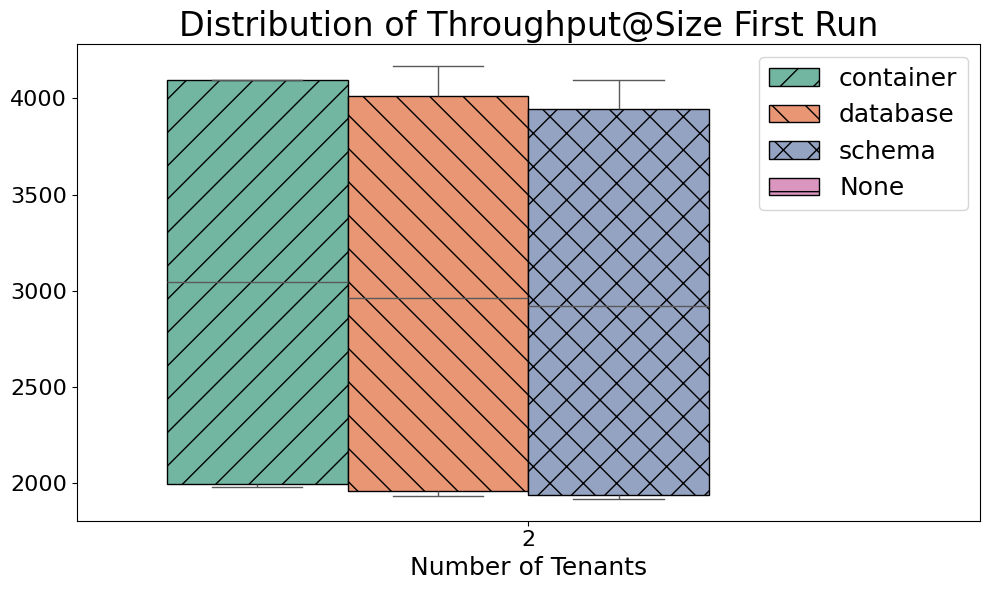

In [25]:
plot_boxplots(df_performance_first, y='Throughput@Size', title='Distribution of Throughput@Size First Run', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

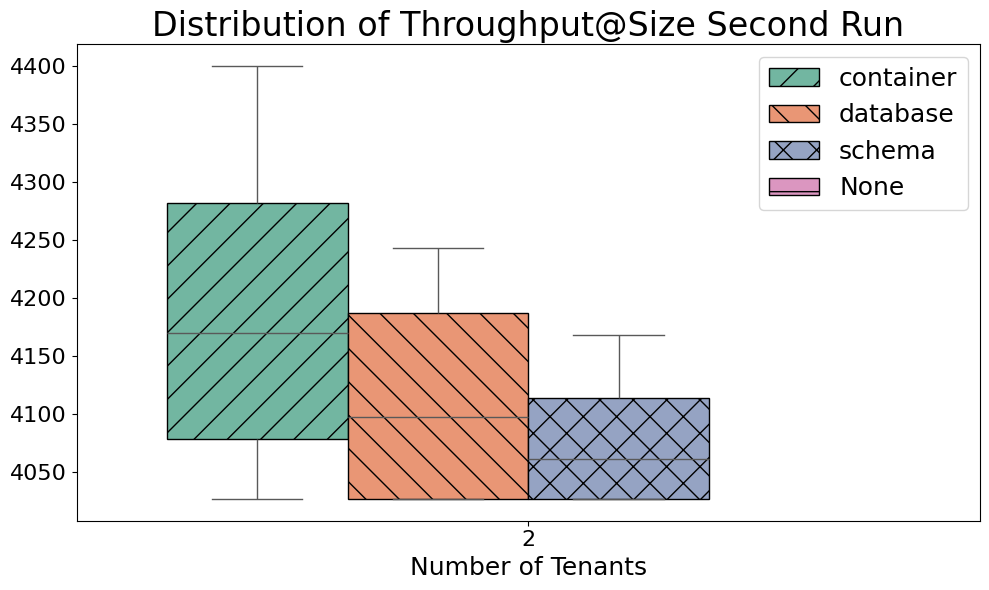

In [26]:
plot_boxplots(df_performance_second, y='Throughput@Size', title='Distribution of Throughput@Size Second Run', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

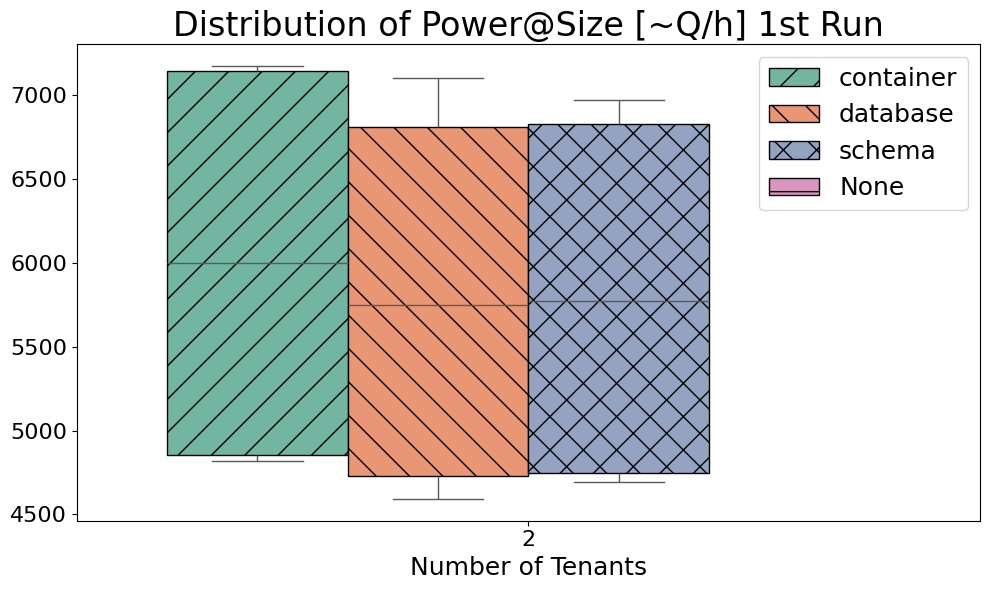

In [27]:
plot_boxplots(df_performance_first, y='Power@Size [~Q/h]', title=r'Distribution of Power@Size [~Q/h] 1st Run', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

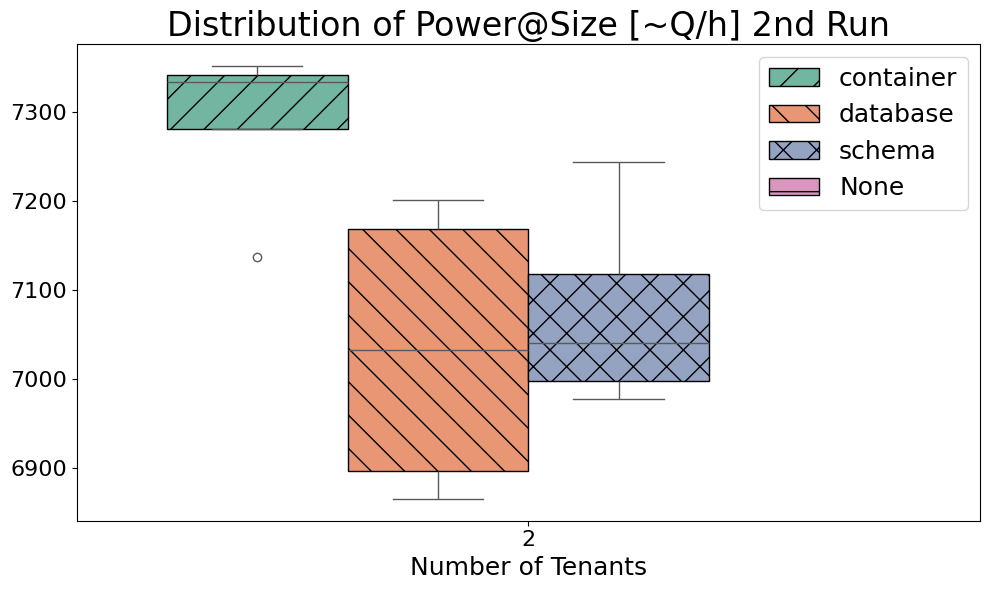

In [28]:
plot_boxplots(df_performance_second, y='Power@Size [~Q/h]', title=r'Distribution of Power@Size [~Q/h] 2nd Run', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

# Performance Results per Total

In [29]:
collect.get_performance_single().T

DBMS,PostgreSQL-BHT-1-0-1-1-1,PostgreSQL-BHT-1-1-1-1-1,PostgreSQL-BHT-1-0-1-2-1,PostgreSQL-BHT-1-1-1-2-1,PostgreSQL-BHT-1-0-2-1-1,PostgreSQL-BHT-1-1-2-1-1,PostgreSQL-BHT-1-0-2-2-1,PostgreSQL-BHT-1-1-2-2-1
total_timer_execution,1.514037,1.505426,1.473585,1.471666,2.241912,2.218321,1.468991,1.513185
Power@Size [~Q/h],7133.248561,7174.050758,7329.063836,7338.621825,4817.316692,4868.547383,7351.983147,7137.262208
Geo Times [s],1.514037,1.505426,1.473585,1.471666,2.241912,2.218321,1.468991,1.513185
SF,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0
experiment_run,1,1,1,1,2,2,2,2
client,1,1,2,2,1,1,2,2
time [s],58,58,54,56,119,120,58,59
count,1,1,1,1,1,1,1,1
num_of_queries,22,22,22,22,22,22,22,22
Throughput@Size,4096.55,4096.55,4400.0,4242.86,1996.64,1980.0,4096.55,4027.12


In [30]:
collect.get_performance_all_single()

,total_timer_execution,Power@Size [~Q/h],Geo Times [s],SF,experiment_run,client,time [s],count,num_of_queries,Throughput@Size,code,type,num_tenants,vol_tenants
DBMS,,,,,,,,,,,,,,
PostgreSQL-BHT-1-0-1-1-1,1.514037,7133.248561,1.514037,3.0,1,1,58,1,22,4096.55,1776011403,container,2,False
PostgreSQL-BHT-1-1-1-1-1,1.505426,7174.050758,1.505426,3.0,1,1,58,1,22,4096.55,1776011403,container,2,False
PostgreSQL-BHT-1-0-1-2-1,1.473585,7329.063836,1.473585,3.0,1,2,54,1,22,4400.00,1776011403,container,2,False
PostgreSQL-BHT-1-1-1-2-1,1.471666,7338.621825,1.471666,3.0,1,2,56,1,22,4242.86,1776011403,container,2,False
PostgreSQL-BHT-1-0-2-1-1,2.241912,4817.316692,2.241912,3.0,2,1,119,1,22,1996.64,1776011403,container,2,False
PostgreSQL-BHT-1-1-2-1-1,2.218321,4868.547383,2.218321,3.0,2,1,120,1,22,1980.00,1776011403,container,2,False
PostgreSQL-BHT-1-0-2-2-1,1.468991,7351.983147,1.468991,3.0,2,2,58,1,22,4096.55,1776011403,container,2,False
PostgreSQL-BHT-1-1-2-2-1,1.513185,7137.262208,1.513185,3.0,2,2,59,1,22,4027.12,1776011403,container,2,False
PostgreSQL-BHT-2-1-1-1,1.608019,6716.338137,1.608019,3.0,1,1,60,1,22,3960.00,1776009655,database,2,False


In [31]:
df_performance = collect.get_performance_all()

df_performance_first = df_performance[df_performance['client']==1]
df_performance_second = df_performance[df_performance['client']==2]

df_performance.dropna(inplace=True)
df_performance_first

AttributeError: 'dbmsbenchmarker' object has no attribute 'benchmarking_aggregate_by_parallel_pods'

In [ ]:
df_performance.T

In [ ]:
df1=collect.get_performance_single()
col1=set(df1.columns)
df2=collect.get_performance_all()
col2=set(df2.columns)
col1.difference(col2), col2.difference(col1)

In [ ]:
import seaborn as sns

sns.barplot(data=df_performance, x='experiment_run', y='Goodput (requests/second)', hue='client')
plt.show()


In [ ]:
plot_bars(df_performance, y='Goodput (requests/second)', title='Goodput [req/s]', estimator='min', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

In [ ]:
plot_bars(df_performance_first, y='Goodput (requests/second)', title='Goodput First Run [req/s]', estimator='min', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

In [ ]:
plot_bars(df_performance_second, y='Goodput (requests/second)', title='Goodput Second Run [req/s]', estimator='min', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

In [ ]:
plot_bars(df_performance, y='Latency Distribution.Average Latency (microseconds)', title=r'Average Latency [$\mu s$]', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

In [ ]:
plot_bars(df_performance_first, y='Latency Distribution.Average Latency (microseconds)', title=r'Average Latency First Run [$\mu s$]', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

In [ ]:
plot_bars(df_performance_second, y='Latency Distribution.Average Latency (microseconds)', title=r'Average Latency Second Run [$\mu s$]', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

In [ ]:
plot_bars(df_performance, y='num_errors', title='Deadlocks', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

In [ ]:
df_performance = collect.get_loading_time_max_all()

df_performance_first = df_performance[df_performance['client']=='1']
df_performance_second = df_performance[df_performance['client']=='2']

df_performance

In [ ]:
df_performance_first = df_performance[df_performance['client'] == '1']
# Divide datadisk by the count of rows with the same type and num_tenants
df = df_performance_first.copy()
# Create a mask for rows where type is not "container"
mask = df['type'] != 'container'

# Only apply the group count to the relevant rows
group_counts = df[mask].groupby(['type', 'num_tenants'])['datadisk'].transform('count')

# Initialize the column with NaN (or 0, if preferred)
df['datadisk_normalized'] = df['datadisk'] / 1024

# Apply the normalized value only where the mask is True
df.loc[mask, 'datadisk_normalized'] = df.loc[mask, 'datadisk'] / group_counts / 1024

plot_bars(df, y='datadisk_normalized', title='Database Size [GB]', estimator='sum', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

In [ ]:
plot_bars(df_performance_first, y='datadisk', title='Database Size [MB]', estimator='sum', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

In [ ]:
plot_bars(df_performance_first, y='time_ingest', title='Time for Ingestion [s]', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

In [ ]:
plot_bars(df_performance_first, y='time_check', title='Time for Vacuum [s]', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

# Hardware Monitoring for Benchmarking Phase

In [ ]:
df_performance = collect.get_monitoring_all(type="stream")

df_performance_first = df_performance[df_performance['client']=='1']
df_performance_second = df_performance[df_performance['client']=='2']

df_performance.T

In [ ]:
plot_bars(df_performance, y='CPU Utilization Time [s]', title='CPU [CPUs]', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

In [ ]:
plot_bars(df_performance_first, y='CPU Utilization Time [s]', title='CPU 1st Run [CPUs]', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

In [ ]:
plot_bars(df_performance_second, y='CPU Utilization Time [s]', title='CPU 2nd Run [CPUs]', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

In [ ]:
plot_bars(df_performance, y='CPU Utilization', title='CPU Utilization [%]', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

## Custom Aggregation

In [ ]:
metric = 'total_cpu_util'

df_performance_series = collect.get_monitoring_timeseries_all(metric)

df_agg = (
    df_performance_series.groupby(["client", "type", "num_tenants"])["value"]
      .max()
      .reset_index()
)
plot_bars(df_agg, y='value', title='Max CPU Utilization [%]', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)
#df_agg

In [ ]:
plot_bars(df_performance, y='CPU Throttle', title='CPU Throttle [%]', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

## Custom Aggregation and Scale

In [ ]:
metric = 'total_cpu_memory'

df_performance_series = collect.get_monitoring_timeseries_all(metric)

df_agg = (
    df_performance_series.groupby(["client", "type", "num_tenants"])["value"]
      .max()
      .reset_index()
)
df_agg['value'] = df_agg['value'] / 1024.
plot_bars(df_agg, y='value', title='Max Memory Usage [GiB]', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

plot_bars(df_performance, y='Memory Usage [MiB]', title='Average Memory Usage [MiB]', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

In [ ]:
metric = 'total_cpu_memory_cached'

df_performance_series = collect.get_monitoring_timeseries_all(metric)

df_agg = (
    df_performance_series.groupby(["client", "type", "num_tenants"])["value"]
      .max()
      .reset_index()
)
df_agg['value'] = df_agg['value'] / 1024.
plot_bars(df_agg, y='value', title='Max Memory Usage Cached [GiB]', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

plot_bars(df_performance, y='Memory Usage Cached [MiB]', title='Average Memory Usage Cached [MiB]', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

# Hardware Monitoring for Loading Phase

In [ ]:
df_performance = collect.get_monitoring_all("loading")

df_performance_first = df_performance[df_performance['client']=='1']
df_performance_second = df_performance[df_performance['client']=='2']

df_performance

In [ ]:
plot_bars(df_performance, y='CPU Utilization Time [s]', title='CPU [CPUs]', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

In [ ]:
plot_bars(df_performance, y='Memory Usage [MiB]', title='Memory Usage [MiB]', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

In [ ]:
plot_bars(df_performance, y='Memory Usage Cached [MiB]', title='Memory Usage Cached [MiB]', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

# Efficiency

In [ ]:
client = 1

df_performance_monitoring = collect.get_monitoring_all(type="stream")
df_performance_monitoring = df_performance_monitoring[df_performance_monitoring['client'] == client]
df_performance = collect.get_performance_all()
#df_performance = df_performance[df_performance['client'] == client]
merged_df = pd.merge(df_performance, df_performance_monitoring, on=['type', 'num_tenants', 'code', 'client'], how='inner')
#merged_df['I_Lat'] = 1./merged_df['E_Lat']
merged_df['E_Tpx'] = merged_df['Goodput (requests/second)'] / merged_df['CPU Utilization Time [s]'] * 600.
merged_df['E_Lat'] = 1./np.sqrt(merged_df['Latency Distribution.Average Latency (microseconds)']*merged_df['CPU Utilization Time [s]']/1E6)
merged_df['E_RAM'] = (merged_df['Goodput (requests/second)']) / merged_df['Memory Usage [MiB]']
merged_df

In [ ]:
plot_bars(merged_df, y='E_Lat', title='1st run - $E_{Lat}$', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

In [ ]:
#plot_bars(merged_df, y='I_Lat', title='1st run - $I_{Lat}$', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

In [ ]:
plot_bars(merged_df, y='E_Tpx', title='1st run - $E_{Tpx}$', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

In [ ]:
plot_bars(merged_df, y='E_RAM', title='1st run - $E_{RAM}$', estimator='min', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

In [ ]:
client = 2

df_performance_monitoring = collect.get_monitoring_all(type="stream")
df_performance_monitoring = df_performance_monitoring[df_performance_monitoring['client'] == client]
df_performance = collect.get_performance_all()
df_performance = df_performance[df_performance['client'] == client]
merged_df = pd.merge(df_performance, df_performance_monitoring, on=['type', 'num_tenants', 'code', 'client'], how='inner')
#merged_df['CPUs/Request'] = merged_df['CPU [CPUs]'] / merged_df['Goodput (requests/second)'] / 600.
merged_df['E_Tpx'] = merged_df['Goodput (requests/second)'] / merged_df['CPU Utilization Time [s]'] * 600.
merged_df['E_Lat'] = 1./np.sqrt(merged_df['Latency Distribution.Average Latency (microseconds)']*merged_df['CPU Utilization Time [s]']/1E6)
merged_df['E_RAM'] = (merged_df['Goodput (requests/second)']) / merged_df['Memory Usage [MiB]']

merged_df

In [ ]:
plot_bars(merged_df, y='E_Lat', title='2nd run - $E_{Lat}$', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

In [ ]:
plot_bars(merged_df, y='E_Tpx', title='2nd run - $E_{Tpx}$', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

In [ ]:
plot_bars(merged_df, y='E_RAM', title='2nd run - $E_{RAM}$', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

In [ ]:
#zip_all_results()